In [1]:
!nvidia-smi

Thu Apr  3 06:49:04 2025       
+---------------------------------------------------------------------------------------+
| NVIDIA-SMI 535.129.03             Driver Version: 535.129.03   CUDA Version: 12.2     |
|-----------------------------------------+----------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id        Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |         Memory-Usage | GPU-Util  Compute M. |
|                                         |                      |               MIG M. |
|=========================================+======================+======================|
|   0  Tesla V100-SXM2-32GB           On  | 00000000:06:00.0 Off |                    0 |
| N/A   29C    P0              44W / 300W |      0MiB / 32768MiB |      0%      Default |
|                                         |                      |                  N/A |
+-----------------------------------------+----------------------+--

In [2]:

from torch.utils.data import DataLoader

from models import get_model
model =  get_model("waterbirds")

In [3]:
import torch
model.load_state_dict(torch.load("best_model.pth", weights_only=True))
model.eval()

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [4]:
from torchvision.models import ResNet
class ResnetWrapper(torch.nn.Module):
    def __init__(self, model: ResNet):
        super(ResnetWrapper, self).__init__()
        self.model = model

    def forward(self, x):
        x_1 = self.model.conv1(x)
        x_2 = self.model.bn1(x_1)
        x_3 = self.model.relu(x_2)
        x_4 = self.model.maxpool(x_3)

        x_5 = self.model.layer1(x_4)
        x_6 = self.model.layer2(x_5)
        x_7 = self.model.layer3(x_6)
        x_8 = self.model.layer4(x_7)

        x_9 = self.model.avgpool(x_8)
        x_10 = torch.flatten(x_9, 1)
        x = self.model.fc(x_10)

        return x, [x_1, x_2, x_3, x_4, x_5, x_6, x_7, x_8, x_9]

wrapper = ResnetWrapper(model)

In [5]:
from models import get_transforms
from utils.waterbirds import WaterbirdsDataset
from flex.data import Dataset
data_transforms = get_transforms("waterbirds")
dataset = Dataset.from_torchvision_dataset(WaterbirdsDataset(train=False)).to_torchvision_dataset(transform=data_transforms)
loader = DataLoader(dataset, batch_size=64, shuffle=False)

/mnt/homeGPU/mariogmarq/causalpy310/lib/python3.10/site-packages/flex/data/dataset.py:131: RuntimeWarning: The input dataset and arguments are not explicitly supported, therefore they might not work as expected.
  warnings.warn(


In [7]:
from tqdm import tqdm
device = torch.device("cuda")
model = model.to(device)
total_entropies = [0 for _ in range(9)]

def compute_entropy(intermediates):
    entropies = []
    for intermediate in intermediates:
        z = intermediate.view(intermediate.shape[0], intermediate.shape[1], -1)
        zz = torch.bmm(z, z.transpose(1, 2))
        eigenvalues = torch.linalg.eigvals(zz).float()
        eigenvalues = torch.where(eigenvalues > 0, eigenvalues, 0)
        trace = zz.diagonal(offset=0, dim1=-1, dim2=-2).sum(-1)
        eigenvalues = eigenvalues / trace.unsqueeze(-1)
        entropy = torch.log(torch.sum(eigenvalues, dim=1))
        entropy = torch.sum(entropy)
        entropies.append(entropy.cpu().float().detach())
    return entropies

for img, _ in tqdm(loader):
    img = img.to(device)
    _, intermediates = wrapper(img)
    entropies = compute_entropy(intermediates)

    for i, e in enumerate(entropies):
        total_entropies[i] += e


  0%|                                                                                                                                                                                | 0/19 [00:00<?, ?it/s]/tmp/ipykernel_4061332/4124468100.py:11: UserWarning: Casting complex values to real discards the imaginary part (Triggered internally at /pytorch/aten/src/ATen/native/Copy.cpp:308.)
  eigenvalues = torch.linalg.eigvals(zz).float()
100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 19/19 [06:11<00:00, 19.58s/it]


In [ ]:
from gc import collect
intermediates = None
collect()

1578

In [9]:
total_entropies

[tensor(0.0002),
 tensor(0.0002),
 tensor(0.0002),
 tensor(0.0001),
 tensor(0.0001),
 tensor(0.0003),
 tensor(0.0005),
 tensor(0.0007),
 tensor(0.0008)]

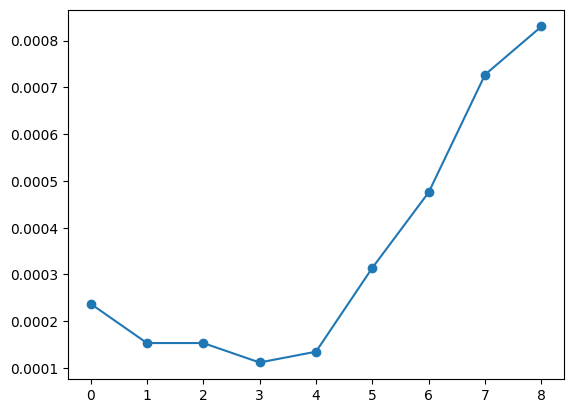

In [10]:
from matplotlib import pyplot as plt
plt.plot(total_entropies, marker='o', linestyle='-', label='Entropy')


In [11]:
wrapper.model.load_state_dict(torch.load("model_federated.pt", weights_only=True))

<All keys matched successfully>

In [ ]:
from gc import collect

model = model.to(device)
total_entropies = [0 for _ in range(9)]


def compute_entropy(intermediates):
    entropies = []
    for intermediate in intermediates:
        z = intermediate.view(intermediate.shape[0], intermediate.shape[1], -1)
        zz = torch.bmm(z, z.transpose(1, 2))
        eigenvalues = torch.linalg.eigvals(zz).float()
        eigenvalues = torch.where(eigenvalues > 0, eigenvalues, 0)
        trace = zz.diagonal(offset=0, dim1=-1, dim2=-2).sum(-1)
        eigenvalues = eigenvalues / trace.unsqueeze(-1)
        entropy = torch.log(torch.sum(eigenvalues, dim=1))
        entropy = torch.sum(entropy)
        entropies.append(entropy.cpu().float().detach())
    return entropies


for img, _ in tqdm(loader):
    img = img.to(device)
    _, intermediates = wrapper(img)
    entropies = compute_entropy(intermediates)

    for i, e in enumerate(entropies):
        total_entropies[i] += e

intermediates = None
collect()

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 19/19 [05:18<00:00, 16.78s/it]


491

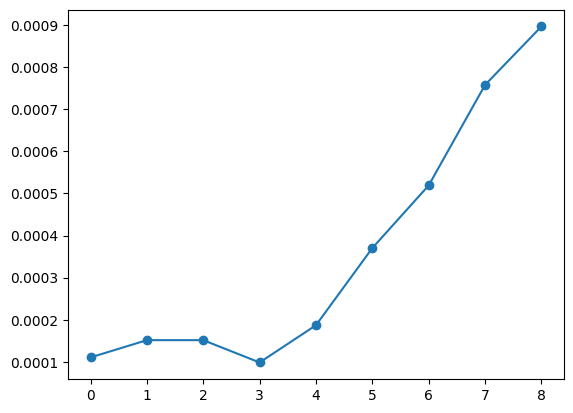

In [14]:
from matplotlib import pyplot as plt
plt.plot(total_entropies, marker='o', linestyle='-', label='Entropy Federated')

In [22]:
model.state_dict().keys()

odict_keys(['conv1.weight', 'bn1.weight', 'bn1.bias', 'bn1.running_mean', 'bn1.running_var', 'bn1.num_batches_tracked', 'layer1.0.conv1.weight', 'layer1.0.bn1.weight', 'layer1.0.bn1.bias', 'layer1.0.bn1.running_mean', 'layer1.0.bn1.running_var', 'layer1.0.bn1.num_batches_tracked', 'layer1.0.conv2.weight', 'layer1.0.bn2.weight', 'layer1.0.bn2.bias', 'layer1.0.bn2.running_mean', 'layer1.0.bn2.running_var', 'layer1.0.bn2.num_batches_tracked', 'layer1.1.conv1.weight', 'layer1.1.bn1.weight', 'layer1.1.bn1.bias', 'layer1.1.bn1.running_mean', 'layer1.1.bn1.running_var', 'layer1.1.bn1.num_batches_tracked', 'layer1.1.conv2.weight', 'layer1.1.bn2.weight', 'layer1.1.bn2.bias', 'layer1.1.bn2.running_mean', 'layer1.1.bn2.running_var', 'layer1.1.bn2.num_batches_tracked', 'layer2.0.conv1.weight', 'layer2.0.bn1.weight', 'layer2.0.bn1.bias', 'layer2.0.bn1.running_mean', 'layer2.0.bn1.running_var', 'layer2.0.bn1.num_batches_tracked', 'layer2.0.conv2.weight', 'layer2.0.bn2.weight', 'layer2.0.bn2.bias', '